# METRICS VISUALIZATION

In [1]:
import pandas as pd
import numpy as np
import os

### remove zero-exressed targets

In [ ]:
from pathlib import Path
here = Path(__file__).resolve().parent
final_train_test_inference = here.parent
ml_pipeline = final_train_test_inference.parent

cpm_tcga = pd.read_parquet(ml_pipeline / 'prepare_train_data/data/tcga_mir_cpm_mature.parquet')
cpm_gtex = pd.read_parquet(ml_pipeline / 'prepare_train_data/data/gtex_mir_cpm_mature.parquet')
cpm_sc = pd.read_parquet(ml_pipeline / 'data/sc_TRAIN/Y_TRAIN_K1.parquet')

In [17]:
tcga_zero = cpm_tcga[cpm_tcga.sum(axis=1) == 0].index.tolist()
gtex_zero = cpm_gtex[cpm_gtex.sum(axis=1) == 0].index.tolist()
sc_zero = cpm_sc[cpm_sc.sum(axis=1) == 0].index.tolist()

print(f'TCGA: {len(tcga_zero)}, GTEx: {len(gtex_zero)}, SC: {len(sc_zero)}')

TCGA: 0, GTEx: 15, SC: 0


In [ ]:
with open('zero_expressed_mirs.txt', 'w') as f:
    for mir in gtex_zero:
        f.write(f"{mir}\n")

### scRNA-seq metrics

In [6]:
df = pd.read_csv('K1_K10_test_metrics.csv', index_col=0)
df.rename(columns={'R2_K1': 'K1', 'R2_K2': 'K2', 'R2_K3': 'K3', 'R2_K4': 'K4', 'R2_K5': 'K5', 'R2_K10': 'K10'}, inplace=True)
df

,K1,K2,K3,K4,K5,K10,n_sc,n_bulk,n_total
target,,,,,,,,,
hsa-let-7a-2-3p,0.050805,0.115669,0.172018,0.241204,0.275982,0.480928,36,724,760
hsa-let-7a-3p,0.360118,0.418064,0.478168,0.519095,0.538943,0.566822,186,50,236
hsa-let-7a-5p,0.624040,0.792798,0.922942,0.935838,0.943755,0.952733,154,235,389
hsa-let-7b-5p,0.836182,0.784030,0.761057,0.740283,0.728759,0.734769,298,50,348
hsa-let-7c-3p,0.008840,0.095973,0.114397,0.151361,0.162221,0.206518,33,50,83
...,...,...,...,...,...,...,...,...,...
hsa-mir-96-5p,0.185428,0.228006,0.452833,0.495680,0.517880,0.818616,108,100,208
hsa-mir-98-5p,0.606884,0.755220,0.817675,0.825570,0.842848,0.829487,175,547,722
hsa-mir-99a-5p,0.449056,0.675581,0.764297,0.844941,0.872843,0.910759,226,50,276


In [7]:
df = df.loc[~df.index.isin(gtex_zero)]

In [8]:
feat_cols = ['K1', 'K2', 'K3', 'K4', 'K5', 'K10']
df = df[feat_cols]
df

,K1,K2,K3,K4,K5,K10
target,,,,,,
hsa-let-7a-2-3p,0.050805,0.115669,0.172018,0.241204,0.275982,0.480928
hsa-let-7a-3p,0.360118,0.418064,0.478168,0.519095,0.538943,0.566822
hsa-let-7b-5p,0.836182,0.784030,0.761057,0.740283,0.728759,0.734769
hsa-let-7c-3p,0.008840,0.095973,0.114397,0.151361,0.162221,0.206518
hsa-let-7d-5p,0.674738,0.752040,0.810637,0.803902,0.797063,0.808359
...,...,...,...,...,...,...
hsa-mir-96-5p,0.185428,0.228006,0.452833,0.495680,0.517880,0.818616
hsa-mir-98-5p,0.606884,0.755220,0.817675,0.825570,0.842848,0.829487
hsa-mir-99a-5p,0.449056,0.675581,0.764297,0.844941,0.872843,0.910759


In [61]:
print('scRNA-seq full results')
means = []
medians = []
for col in df.columns:
    print(f'{col}')
    print(f'mean: {df[col].mean()}')
    print(f'median: {df[col].median()}')
    print(f'max: {df[col].max()}')
    print(f'min: {df[col].min()}')
    means.append(df[col].mean())
    medians.append(df[col].median())

scRNA-seq full results
K1
mean: 0.20364596766523285
median: 0.0971412118693229
max: 0.9503319675955416
min: -0.3661277050092562
K2
mean: 0.24686101264894908
median: 0.135458891698268
max: 0.9696158788316068
min: -2.2790765953332146
K3
mean: 0.31031355824157825
median: 0.2112949950142001
max: 0.9785017136336088
min: -1.354082666295576
K4
mean: 0.3415954421558987
median: 0.2549996438521134
max: 0.9834050272722216
min: -1.928973126612819
K5
mean: 0.35921861156134755
median: 0.2884637728632661
max: 0.9870493907075316
min: -2.5893549411440886
K10
mean: 0.39162920858529743
median: 0.38587898899003037
max: 0.9939800588710684
min: -1.4064123042530283


### bulk test metrics

In [69]:
df_bulk = pd.read_csv('bulk_test_metrics.csv', index_col=0)
df_bulk = df_bulk.loc[~df_bulk.index.isin(gtex_zero)]
df_bulk

,status,R2_bulk,n_bulk_test,n_sc,n_bulk,n_total,fallback
target,,,,,,,
hsa-let-7a-2-3p,ok,0.572541,5337,36,724,760,False
hsa-let-7a-3p,ok,0.693791,5337,186,50,236,False
hsa-let-7b-5p,ok,0.434186,5337,298,50,348,False
hsa-let-7c-3p,ok,0.563162,5337,33,50,83,False
hsa-let-7d-5p,ok,0.625264,5337,241,100,341,False
...,...,...,...,...,...,...,...
hsa-mir-96-5p,ok,0.570132,5337,108,100,208,False
hsa-mir-98-5p,ok,0.796111,5337,175,547,722,False
hsa-mir-99a-5p,ok,0.895675,5337,226,50,276,False


In [79]:
bulk_eligible_set = df_bulk[df_bulk['R2_bulk'] > 0.4].index.tolist()
len(bulk_eligible_set)

275

In [77]:
print('Bulk test metrics:')
print(f"Mean: {df_bulk['R2_bulk'].mean()}")
print(f"Median: {df_bulk['R2_bulk'].median()}")
print(f"Max: {df_bulk['R2_bulk'].max()}")
print(f"Min: {df_bulk['R2_bulk'].min()}")

Bulk test metrics:
Mean: 0.6499270685354978
Median: 0.7237865376839526
Max: 0.9785604216935312
Min: -1.6590531262600563


In [70]:
resolution = list(df.columns) + ['BULK']
means.append(df_bulk['R2_bulk'].mean())
medians.append(df_bulk['R2_bulk'].median())

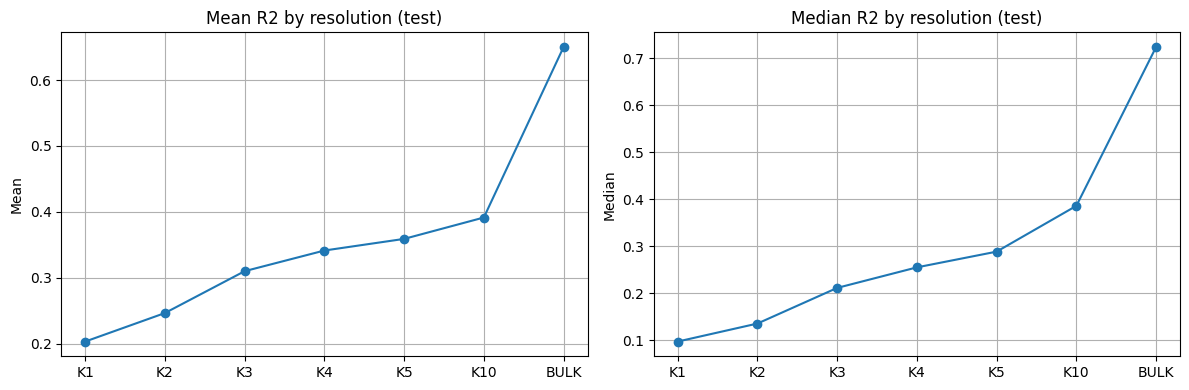

In [71]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))


ax1.plot(resolution, means, marker='o')
ax1.set_title("Mean R2 by resolution (test)")
ax1.set_ylabel("Mean")
ax1.grid(True)


ax2.plot(resolution, medians, marker='o')
ax2.set_title("Median R2 by resolution (test)")
ax2.set_ylabel("Median")
ax2.grid(True)

plt.tight_layout()
plt.savefig("figures/mean_median_by_K.png", dpi=300, bbox_inches="tight")
plt.show()

### select optimal K

In [80]:
def select_optimal_k(df, rel_delta=0.05):
    Ks = [1, 2, 3, 4, 5, 10]

    dict_predict = {}

    for mir in df.index:
        
        scores = df.loc[mir].values
        best_score = scores.max()

        if best_score > 0.4:

            candidate_idx = np.where(
                scores >= best_score * (1 - rel_delta)
            )[0]

            chosen_idx = candidate_idx[0]  # минимальный K среди подходящих

            K = Ks[chosen_idx]

            dict_predict.setdefault(f'K{K}', [])
            dict_predict[f'K{K}'].append(mir)

    return dict_predict


In [81]:
dict_predict = select_optimal_k(df, rel_delta=0.075)

In [84]:
sc_eligible_set = []
for key in dict_predict.keys():
    sc_eligible_set.extend(dict_predict[key])

len(sc_eligible_set)

156

In [85]:
eligible_mirs = sorted(list(set(sc_eligible_set) & set(bulk_eligible_set)))
len(eligible_mirs)

152

In [90]:
dict_predict['eligible_mirs'] = eligible_mirs

eligible = set(dict_predict['eligible_mirs'])

for k in dict_predict:
    if k.startswith('K'):
        dict_predict[k] = [mir for mir in dict_predict[k] if mir in eligible]

In [91]:
import json

with open('prediction_config.json', 'w') as f:
    json.dump(dict_predict, f)

### eligible mir metrics

In [95]:
bulk_r2_trimmed = np.array(df_bulk.loc[eligible_mirs]['R2_bulk'])
print('BULK:')
      
print(f'Mean R2: {np.mean(bulk_r2_trimmed)}')
print(f'Median R2: {np.median(bulk_r2_trimmed)}')
print(f'Max R2: {np.max(bulk_r2_trimmed)}')
print(f'Min R2: {np.min(bulk_r2_trimmed)}')

BULK:
Mean R2: 0.7521873916707807
Median R2: 0.7694394523624519
Max R2: 0.960666686357517
Min R2: 0.4195273462875489


In [97]:
# final metrics of scRNA-seq across eligible mirs
res = []
for k, v in dict_predict.items():
    if k != 'eligible_mirs':
        res.extend(df.loc[v][k])
res = np.array(res)

print('scRNA (optimal K):')
print(f'Mean R2: {np.mean(res)}')
print(f'Median R2: {np.median(res)}')
print(f'Max R2: {np.max(res)}')
print(f'Min R2: {np.min(res)}')

scRNA (optimal K):
Mean R2: 0.7825836035372691
Median R2: 0.8181457184497332
Max R2: 0.9687530582312788
Min R2: 0.4018973633727697


In [121]:
for key, value in dict_predict.items():
    print(f'{key}: {len(value)}')

K10: 69
K5: 20
K1: 10
K2: 18
K3: 16
K4: 19


## Figures

In [99]:
del(dict_predict['eligible_mirs'])

/tmp/ipykernel_26/2973080766.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_26/2973080766.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="")


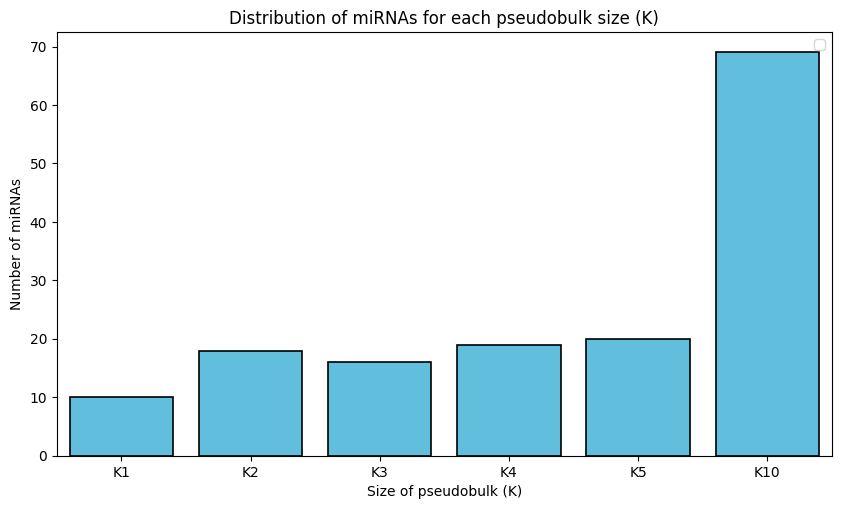

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

OUT = Path('figures')
def _save(fig: plt.Figure, name: str) -> None:
    OUT.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUT / f"{name}.pdf", format="pdf", bbox_inches="tight", facecolor="white")
    fig.savefig(OUT / f"{name}.png", format="png", bbox_inches="tight", facecolor="white")
    plt.close(fig)


def _miRNA_distribution_by_k(dict_predict: dict) -> None:
    rows = []

    for k_val, mirnas in dict_predict.items():
        rows.append({
            "K_value": k_val,
            "count": len(mirnas)
        })

    plot_df = pd.DataFrame(rows)

    # порядок K
    k_order = sorted(plot_df["K_value"].unique(), key=lambda x: int(x.replace("K", "")))

    plot_df["K_value"] = pd.Categorical(
        plot_df["K_value"],
        categories=k_order,
        ordered=True
    )

    fig, ax = plt.subplots(figsize=(10, 5.5))

    col = '#4cc9f0'
    sns.barplot(
        data=plot_df,
        x="K_value",
        y="count",
        palette={
            "K1": col,
            "K2": col,
            "K3": col,
            "K4": col,
            "K5": col,
            "K10": col
        },
        edgecolor="black",
        linewidth=1.2,
        ax=ax,
    )

    ax.set_xlabel("Size of pseudobulk (K)")
    ax.set_ylabel("Number of miRNAs")
    ax.set_title("Distribution of miRNAs for each pseudobulk size (K)")
    ax.legend(title="")

    _save(fig, "miRNA_distribution_by_k")

    return fig

_miRNA_distribution_by_k(dict_predict)

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

K_COHORTS = ("K1", "K2", "K3", "K4", "K5", "K10", 'BULK')
R2_THRESHOLD = 0.4
K_COLORS = {
    "K1": "#1f77b4",
    "K2": "#2ca02c",
    "K3": "#ff7f0e",
    "K4": "#d62728",
    "K5": "#9467bd",
    "K10": "#FF1493",
    "BULK": "black"
}


def _save(fig: plt.Figure, name: str) -> None:
    OUT.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUT / f"{name}.pdf", format="pdf", bbox_inches="tight", facecolor="white")
    fig.savefig(OUT / f"{name}.png", format="png", bbox_inches="tight", facecolor="white")
    plt.close(fig)



def _r2_lines_by_target(df: pd.DataFrame) -> None:
    order = df.sort_values("R2_K1")["target"].tolist()
    x = np.arange(len(order))
    fig, ax = plt.subplots(figsize=(18, 7))

    for k in K_COHORTS:
        col = f"R2_{k}"
        y = df.set_index("target").reindex(order)[col].to_numpy()
        lw = 2.8 if k == "K1" else 1.6
        alpha = 1.0 if k in ("K1", "K10") else 0.75
        zorder = 4 if k == "K10" else (3 if k == "K1" else 2)
        ax.plot(x, y, label=k, color=K_COLORS[k], lw=lw, alpha=alpha, zorder=zorder)

    ax.axhline(R2_THRESHOLD, color="black", ls="--", lw=1, alpha=0.45, label=f"R²={R2_THRESHOLD}")
    ax.set_xlabel("Targets (sorted by K1 test R²)")
    ax.set_ylabel("Test R²")
    ax.set_title("Per-target R² across K1–K10 (CatBoost+TabM+ResNet stack)")
    tick_step = 10
    ticks = x[::tick_step]
    ax.set_xticks(ticks)
    #ax.set_xticklabels([order[i] for i in ticks], rotation=65, ha="right", fontsize=6)
    ax.legend(loc="upper left", ncol=4, fontsize=9)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    _save(fig, 'r2_lines_by_target')
    return fig



In [109]:
df_ = pd.read_csv('K1_K10_test_metrics.csv')
df_bulk_ = pd.read_csv('bulk_test_metrics.csv')

merged = df_.merge(df_bulk_[['target', 'R2_bulk']], on = 'target', how = 'left')
merged.rename(columns={'R2_bulk': 'R2_BULK'}, inplace=True)

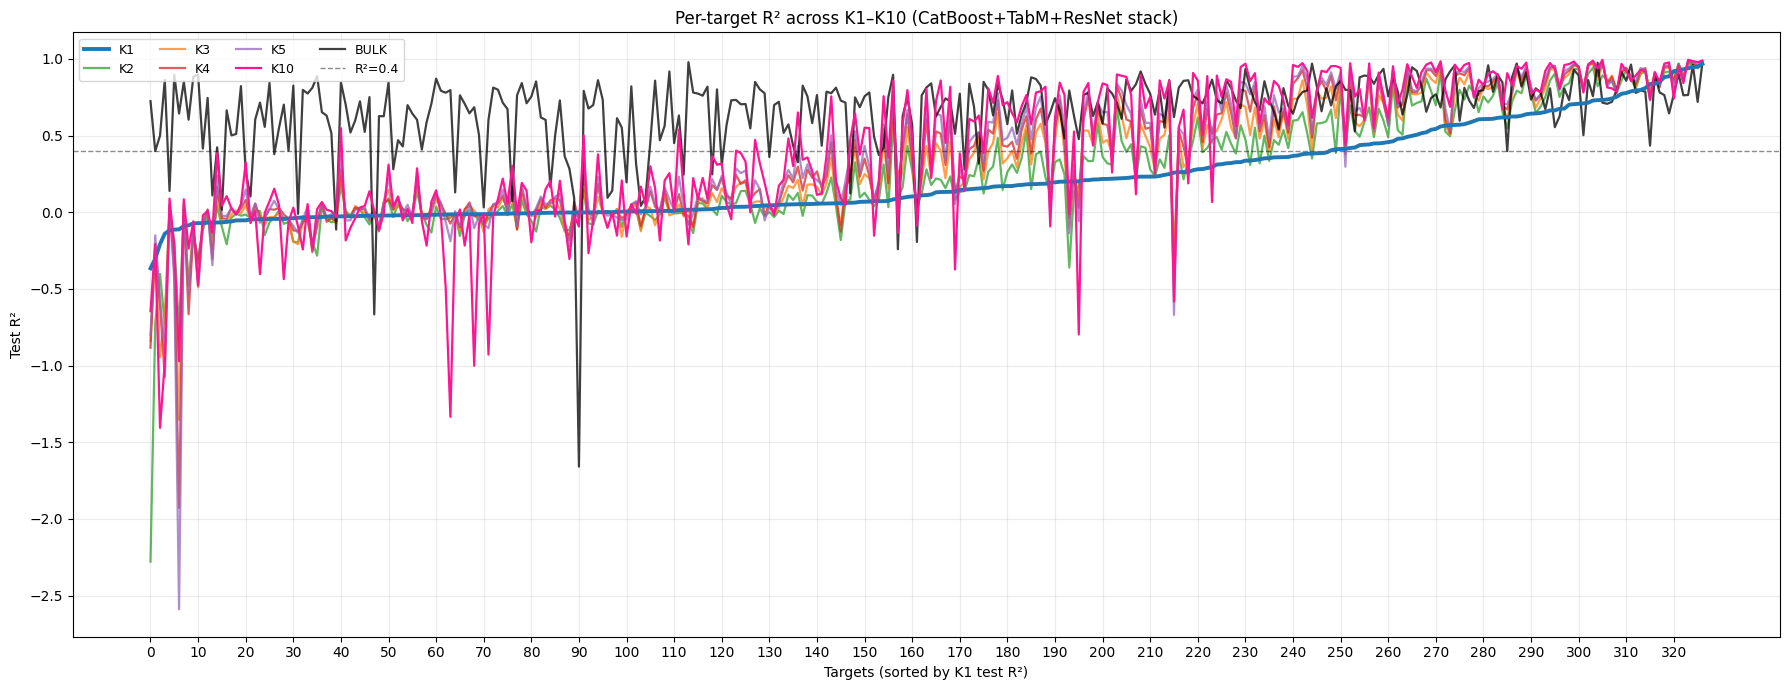

In [110]:
_r2_lines_by_target(merged)

In [111]:
def _r2_mean_median_by_k(df: pd.DataFrame) -> None:
    rows = []
    for k in K_COHORTS:
        col = f"R2_{k}"
        rows.append({"cohort": k, "stat": "mean", "r2": df[col].mean()})
        rows.append({"cohort": k, "stat": "median", "r2": df[col].median()})
    plot_df = pd.DataFrame(rows)
    plot_df["cohort"] = pd.Categorical(plot_df["cohort"], categories=list(K_COHORTS), ordered=True)

    fig, ax = plt.subplots(figsize=(10, 5.5))
    sns.barplot(
        data=plot_df,
        x="cohort",
        y="r2",
        hue="stat",
        order=list(K_COHORTS),
        palette={"mean": "#5f00ff", "median": "#00ffd7"},
        edgecolor='black',
        ax=ax,
    )
    #ax.axhline(R2_THRESHOLD, color="black", ls="--", lw=1, alpha=0.45)
    ax.set_xlabel("Cohort")
    ax.set_ylabel("Test R²")
    ax.set_title("Mean / median test R² across cohorts")
    ax.legend(title="")
    _save(fig, "r2_mean_median_by_k")
    return fig


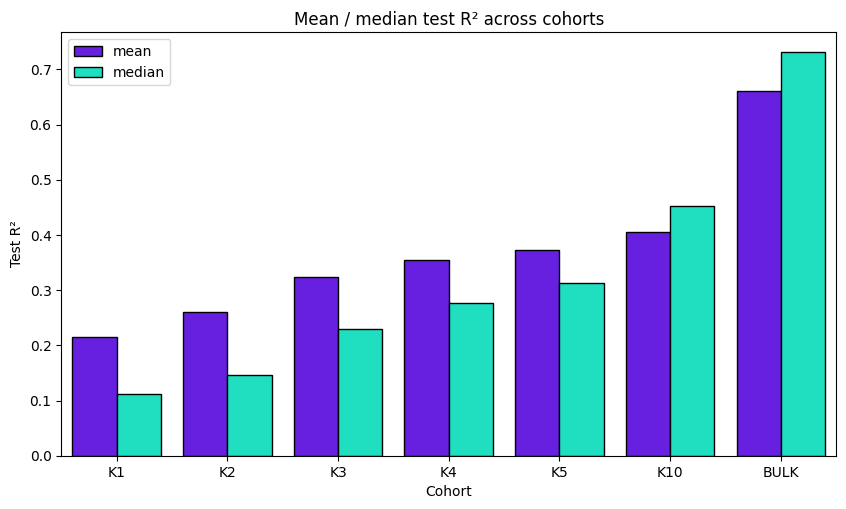

In [112]:
_r2_mean_median_by_k(merged)

In [113]:
ELIGIBLE_COLOR = "#FF1493"
OTHER_COLOR = "#708090"
K_COHORTS = ("K1", "K2", "K3", "K4", "K5", "K10", 'BULK')
R2_COLS = [f"R2_{k}" for k in K_COHORTS]

def _eligible_vs_rest(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    sns.kdeplot(data=df, x="R2_K1", hue="eligible", fill=True, common_norm=False, ax=axes[0], palette={
        True: ELIGIBLE_COLOR,
        False: OTHER_COLOR,
    })
    axes[0].axvline(R2_THRESHOLD, color="black", ls="--", lw=1, alpha=0.45)
    axes[0].set_xlabel("K1 test R²")
    axes[0].set_title("K1 R² density: eligible vs rest")
    axes[0].legend(title="", labels=[f"eligible (n={df['eligible'].sum()})", f"other (n={(~df['eligible']).sum()})"])

    long = df[df["eligible"]].melt(
        id_vars="target",
        value_vars=R2_COLS,
        var_name="cohort",
        value_name="r2",
    )
    long["cohort"] = long["cohort"].str.replace("R2_", "", regex=False)
    long["cohort"] = pd.Categorical(long["cohort"], categories=list(K_COHORTS), ordered=True)
    sns.boxplot(
        data=long,
        x="cohort",
        y="r2",
        order=list(K_COHORTS),
        palette=[K_COLORS[k] for k in K_COHORTS],
        ax=axes[1],
    )
    axes[1].axhline(R2_THRESHOLD, color="black", ls="--", lw=1, alpha=0.45)
    axes[1].set_xlabel("Assigned cohort")
    axes[1].set_ylabel("Test R² at assigned K")
    axes[1].set_title("Eligible targets: R² at assigned cohort")
    fig.tight_layout()
    _save(fig, "eligible_vs_rest_k1")
    return fig

In [114]:
merged['eligible'] = merged['target'].isin(eligible_mirs)

/tmp/ipykernel_26/645403436.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


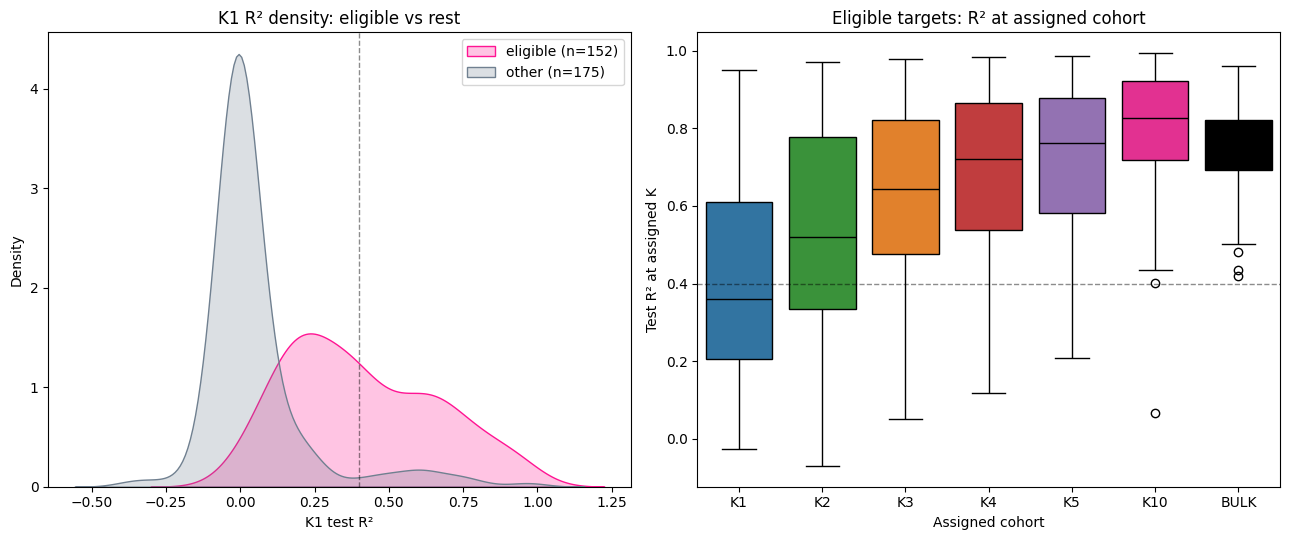

In [115]:
_eligible_vs_rest(merged)

In [49]:
from scipy import stats
import matplotlib.colors as mcolors
def _scatter_features_vs_k1(df: pd.DataFrame, x_col: str, x_label: str, fname: str, color: str = '#00ffd7') -> None:
    fig, ax = plt.subplots(figsize=(9, 6.5))
    
    face = mcolors.to_rgba(color, alpha=0.5)

    ax.scatter(
            df[x_col],
            df["R2_K1"],
            c=face,
            s=42,
            edgecolors="black",
            linewidths=0.4
        )

    x = df[x_col].to_numpy(dtype=float)
    y = df["R2_K1"].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() >= 3:
        slope, intercept, r, p, _ = stats.linregress(x[mask], y[mask])
        xs = np.linspace(x[mask].min(), x[mask].max(), 100)
        ax.plot(xs, slope * xs + intercept, color="#222222", lw=2, alpha=0.85, zorder=1)
        ax.text(
            0.03,
            0.97,
            f"Pearson r = {r:.3f}\np = {p:.2e}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.9, edgecolor="#ccc"),
        )

    #ax.axhline(R2_THRESHOLD, color="black", ls="--", lw=1, alpha=0.45)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Test R² (K1 single-cell)")
    ax.set_title(f"K1 performance vs {x_label}")
    #ax.legend(loc="lower right", framealpha=0.95)
    _save(fig, fname)
    return fig

/mnt/jack-1/tmp/ipykernel_3105055/2408930496.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


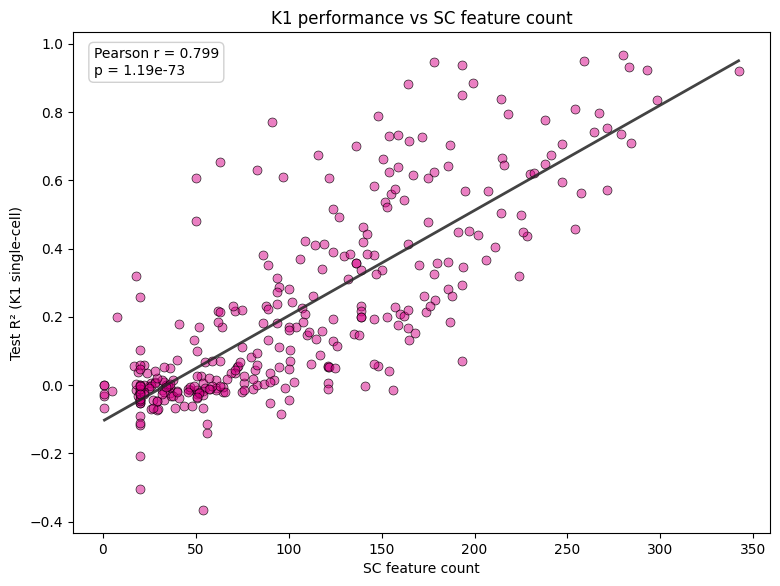

In [50]:
_scatter_features_vs_k1(merged, "n_sc", "SC feature count", 'n_sc_vs_k1', color='#d70087')

/mnt/jack-1/tmp/ipykernel_3105055/2408930496.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


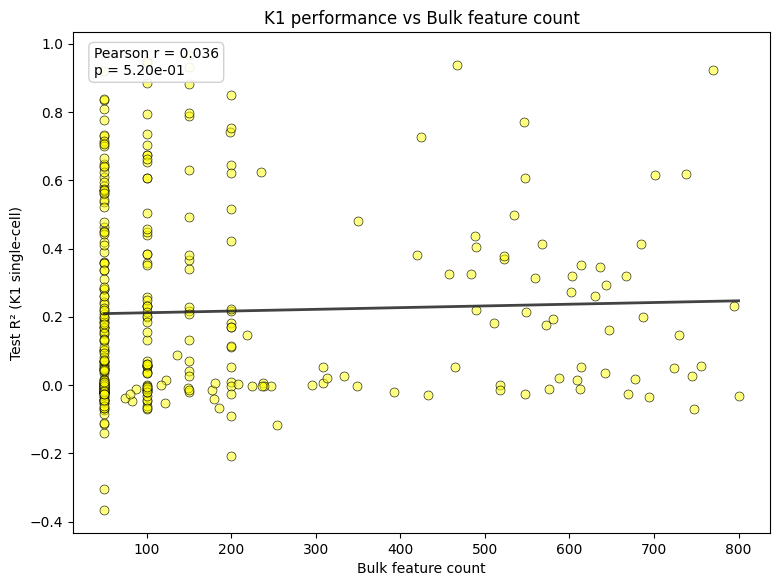

In [51]:
_scatter_features_vs_k1(merged, "n_bulk", "Bulk feature count", 'n_bulk_vs_k1', color='#ffff00')